In [ ]:
import torch
from torch import nn

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Conv2d(1, 6, padding=2, kernel_size=5) # 28x28
        self.l2 = nn.AvgPool2d(kernel_size=2, stride=2) # 14x14
        self.l3 = nn.Conv2d(6, 16, kernel_size=5) # (14-5)/1 + 1 = 10x10
        self.l4 = nn.AvgPool2d(kernel_size=2, stride=2) # 5x5
        self.l5 = nn.Flatten() # 16*5*5
        self.l6 = nn.Linear(16*5*5, 120)
        self.l7 = nn.Linear(120, 84)
        self.l8 = nn.Linear(84, 10)

    def forward(self, x):
        x = x.reshape(-1, 1, 28, 28)
        x = self.l1(x)
        x = self.l2(x)
        x = self.l3(x)
        x = self.l4(x)
        x = self.l5(x)
        x = self.l6(x)
        x = self.l7(x)
        x = self.l8(x)
        return x

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define the transformation: Convert to tensor and normalize
# Fashion-MNIST is grayscale, so we use mean and std for one channel
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Training data
train_set = datasets.FashionMNIST(
    root="data", 
    train=True, 
    download=True, 
    transform=transform
)

# Test data
test_set = datasets.FashionMNIST(
    root="data", 
    train=False, 
    download=True, 
    transform=transform
)

In [ ]:
train_set[0][0].shape

In [14]:
net = CNN()
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.01)

In [15]:
epochs = 10
batch_size = 256
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

In [ ]:
dir(train_loader)

In [16]:
for epoch in range(epochs):
    for X, y in train_loader:
        y_predicted = net(X)
        l = loss(y_predicted, y)
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
    print(f"Epoch: {epoch+1}, Loss: {l.item():.4f}")

Epoch: 1, Loss: 1.0270
Epoch: 2, Loss: 0.6326
Epoch: 3, Loss: 0.7211
Epoch: 4, Loss: 0.5560
Epoch: 5, Loss: 0.7361
Epoch: 6, Loss: 0.4476
Epoch: 7, Loss: 0.5121
Epoch: 8, Loss: 0.4585
Epoch: 9, Loss: 0.6414
Epoch: 10, Loss: 0.4818


In [17]:
net.eval()


CNN(
  (l1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (l2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (l3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (l4): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (l5): Flatten(start_dim=1, end_dim=-1)
  (l6): Linear(in_features=400, out_features=120, bias=True)
  (l7): Linear(in_features=120, out_features=84, bias=True)
  (l8): Linear(in_features=84, out_features=10, bias=True)
)

In [18]:
import matplotlib.pyplot as plt
import numpy as np

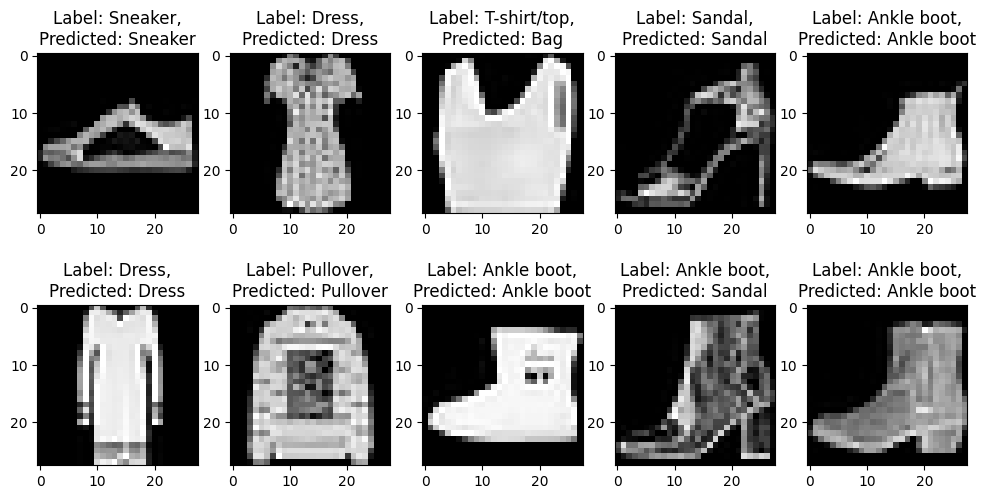

In [21]:
def get_label(index):
    labels = [
        "T-shirt/top",
        "Trouser",
        "Pullover",
        "Dress",
        "Coat",
        "Sandal",
        "Shirt",
        "Sneaker",
        "Bag",
        "Ankle boot"
    ]
    return labels[index]

TestSample = 10
import random
index = [random.randint(0, len(test_set)-1) for _ in range(TestSample)]

plt.subplots(2, 5, figsize=(12, 6))

for i in index:
    img, label = test_set[i]
    predicted_y = net(img.reshape(1, 1, 28, 28))
    _, predicted_label_number = torch.max(predicted_y, 1)
    predicted_label = get_label(predicted_label_number.item())

    img = img.reshape(28, 28)

    plt.subplot(2, 5, index.index(i)+1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Label: {get_label(label)},\nPredicted: {predicted_label}")

plt.show()